#****Import All necessary Libraries****

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#**Data Preprocessing**

#Data cleaning

In [2]:
df = sns.load_dataset('titanic')

In [3]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
df.head()   #Output column = Survived

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [6]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [8]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [9]:
#Missing value percentage
(df.isnull().sum()/df.shape[0])*100

,0
survived,0.000000
pclass,0.000000
sex,0.000000
age,19.865320
sibsp,0.000000
parch,0.000000
fare,0.000000
embarked,0.224467
class,0.000000
who,0.000000


**age - first check outliers,
  embarked - mode,
  deck - drop**

<Axes: xlabel='age'>

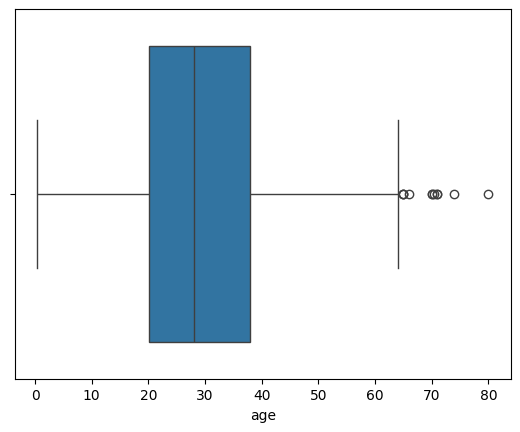

In [10]:
sns.boxplot(df,x = 'age')

In [11]:
df['age'].describe()

,age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


#Find the number of outliers in age columns

In [12]:
#IQR
Q1 = 20.125
Q2 = 28
Q3 = 38
IQR = Q3 - Q1
Lower_bound = Q1 - (1.5*IQR)
Upper_bound = Q3 + (1.5*IQR)

(df['age'] > Upper_bound).sum()

np.int64(11)

In [13]:
(df['age'] < Lower_bound).sum()

np.int64(0)

#Total outliers in age columns is 11. so we use mean

In [14]:
df['age'].fillna(df['age'].mean(),inplace = True)

In [15]:
df['embarked'].mode()

,embarked
0,S


In [16]:
df['embarked'].fillna(df['embarked'].mode()[0],inplace = True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [18]:
df.drop('deck',axis=1,inplace=True)

In [19]:
df[df.duplicated()]
#there is no any uniqe id for finding duplicates so we do not remove deplicates and go forward to data cleaning

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
47,1,3,female,29.699118,0,0,7.7500,Q,Third,woman,False,Queenstown,yes,True
76,0,3,male,29.699118,0,0,7.8958,S,Third,man,True,Southampton,no,True
77,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
87,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
95,0,3,male,29.699118,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.000000,0,0,7.8958,S,Third,man,True,Southampton,no,True
877,0,3,male,19.000000,0,0,7.8958,S,Third,man,True,Southampton,no,True
878,0,3,male,29.699118,0,0,7.8958,S,Third,man,True,Southampton,no,True
884,0,3,male,25.000000,0,0,7.0500,S,Third,man,True,Southampton,no,True


In [20]:
df['who'].unique()

array(['man', 'woman', 'child'], dtype=object)

In [21]:
df['who'].value_counts()

,count
who,
man,537
woman,271
child,83


In [22]:
df.drop(['who','adult_male','alive','alone','embark_town','class'],axis=1,inplace = True)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       891 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [24]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


#EDA (Exploratory Data Analysis)

In [25]:
df['survived'].value_counts()

,count
survived,
0,549
1,342


🎯 Target --
survived → Binary Categorical (Target),
📊 Categorical Features---
pclass → Ordinal Categorical,
sex → Binary Categorical
embarked → Nominal Categorical.
📈 Numerical Features----

Continuous---

age,
fare

Discrete (Count)

sibsp,
parch

In [26]:
# Agar data normal hoga to KDE bell-shaped lag sakti hai.

# Agar skewed hoga to KDE bhi skewed dikhegi.

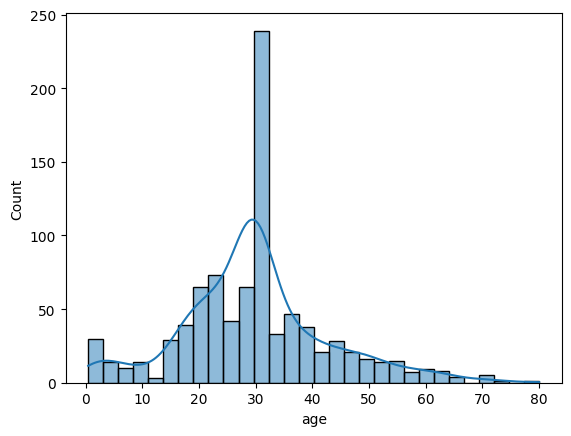

In [27]:
sns.histplot(df['age'],kde = True)
plt.show()

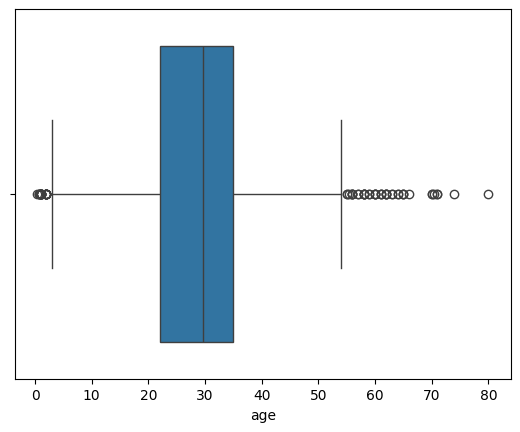

In [28]:
sns.boxplot(df, x = 'age')
plt.show()

In [29]:
df['age'].describe()

,age
count,891.000000
mean,29.699118
std,13.002015
min,0.420000
25%,22.000000
50%,29.699118
75%,35.000000
max,80.000000


In [30]:
df['age'].skew()

np.float64(0.4344880940129925)

### Age Feature Analysis

- Age is slightly right-skewed.
- Few outliers are present.
- Mean and median are almost similar.
- Since outliers are few and age values are realistic, I will keep them.

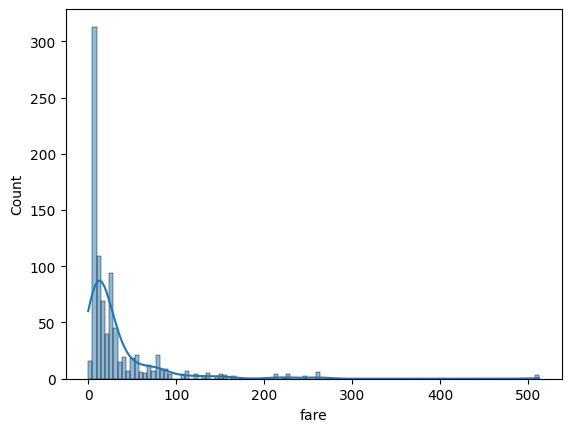

In [31]:
sns.histplot(df['fare'],kde = True)
plt.show()

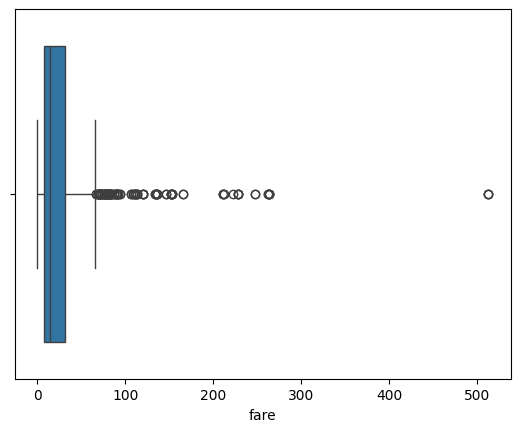

In [32]:
sns.boxplot(df,x ='fare')
plt.show()

In [33]:
df['fare'].describe()

,fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


In [34]:
#IQR
Q1 = 7.910400
Q2 = 14.454200
Q3 = 31
IQR = Q3 - Q1
Lower_bound = Q1 - (1.5*IQR)
Upper_bound = Q3 + (1.5*IQR)

(df['fare'] > Upper_bound).sum()   #Out of 891

np.int64(116)

In [35]:
print("Outlier pecentage",(116/891)*100)

Outlier pecentage 13.019079685746352


In [36]:
df['fare'].skew()

np.float64(4.787316519674893)

### Fare Feature Analysis

- Fare is highly right-skewed (Skewness = 4.7).
- Around 13% observations are identified as outliers using the IQR method.
- Most passengers paid low fares, while only a few paid very high fares.
- Due to the presence of many outliers and high skewness, the median is a better measure of central tendency than the mean.

#**Categorical Feature Analysis**

#Univariate Analysis - Feature ko individually analysis karna

In [37]:
df['sex'].value_counts()

,count
sex,
male,577
female,314


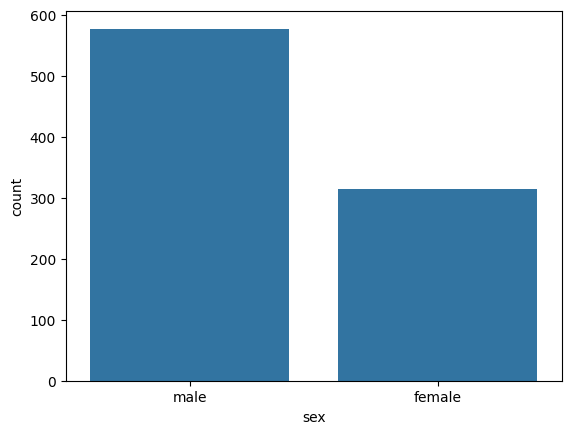

In [38]:
sns.countplot(data=df, x='sex')
plt.show()

In [39]:
df['embarked'].value_counts()

,count
embarked,
S,646
C,168
Q,77


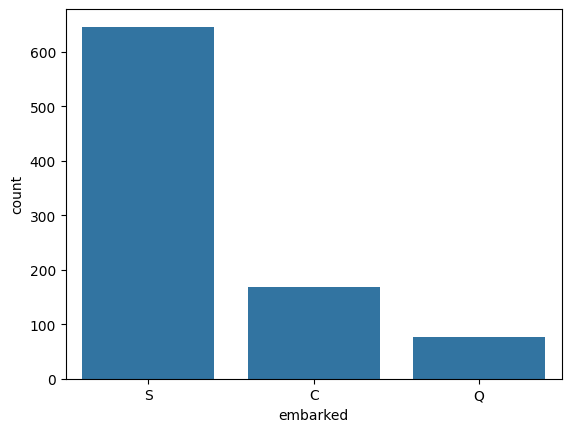

In [40]:
sns.countplot(data = df, x = 'embarked')
plt.show()

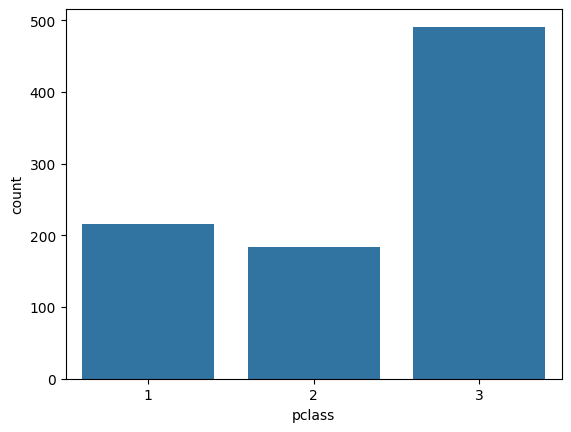

In [41]:
sns.countplot(data = df, x = 'pclass')
plt.show()

#Observation for Univariate Analysis
#Sex - Male were more than female in this data set
#embarked - Most passengers embarked from the S followed by the C and Q
#pclass = Most passengers from 3rd class followed by 1 and 2

#**Bivariate Analysis - Feature VS Target**

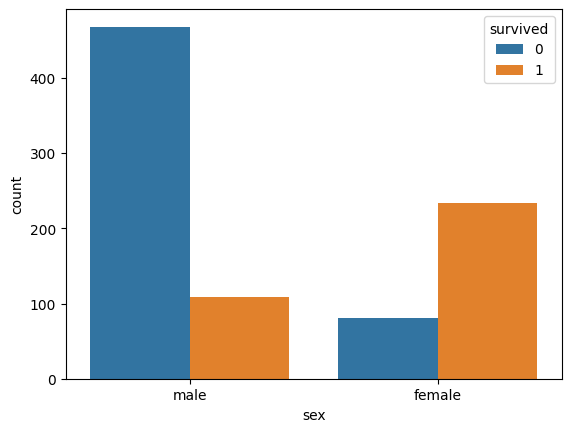

In [42]:
sns.countplot(data=df, x='sex', hue='survived')
plt.show()

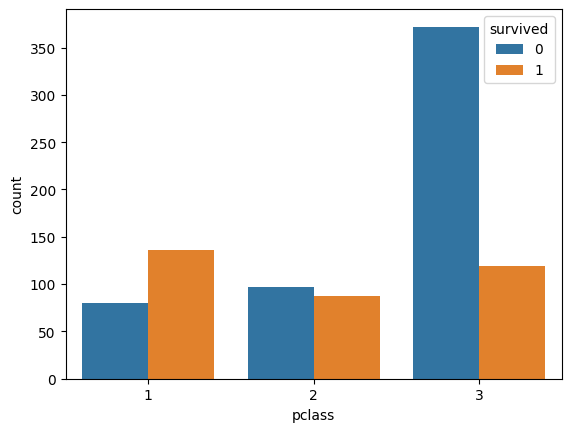

In [43]:
sns.countplot(data=df, x='pclass', hue='survived')
plt.show()

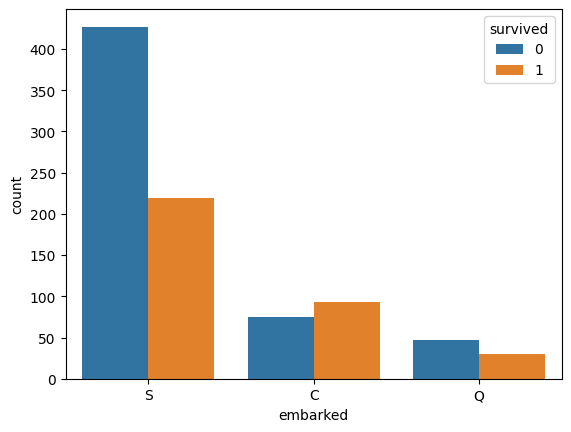

In [44]:
sns.countplot(data=df, x='embarked', hue='survived')
plt.show()

#Bivariate Observation
#sex- Male have lower Survival rate and femal have more survival rate
#pclass - 3rd class have lower rate , 2nd have neutral and 1st have higher survival rate
#embarked - for Passengers from S have lower survival rate and C have higher and Q almost moderate

In [45]:
pd.crosstab(df['embarked'], df['survived'], normalize='index') * 100

survived,0,1
embarked,,
C,44.642857,55.357143
Q,61.038961,38.961039
S,66.099071,33.900929


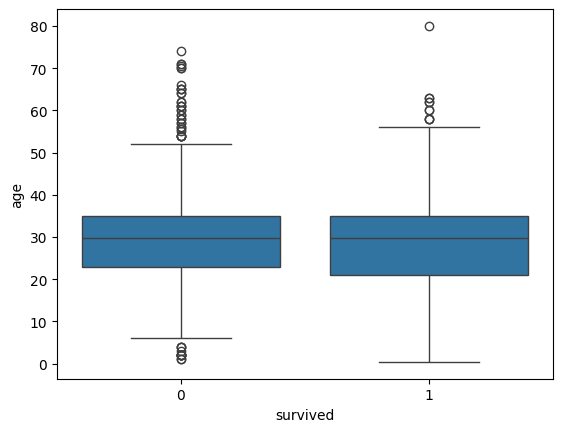

In [46]:
sns.boxplot(data=df, x='survived', y='age')
plt.show()

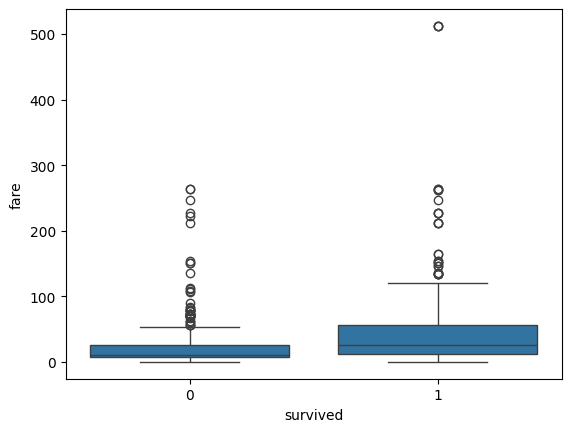

In [47]:
sns.boxplot(data=df, x='survived', y='fare')
plt.show()

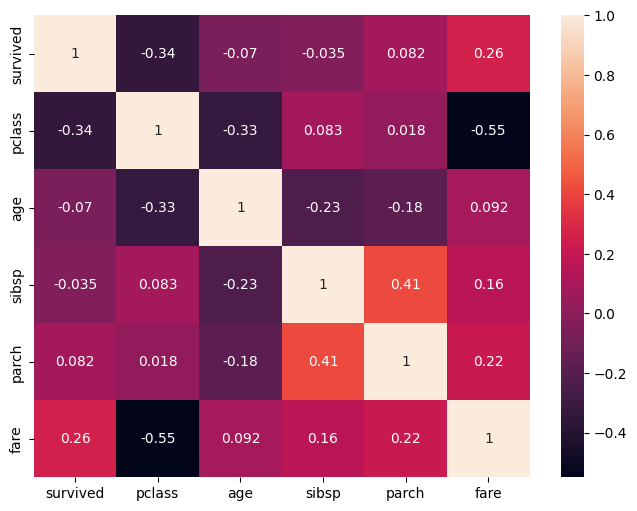

In [48]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.show()

#**Encoding**

Label Encoding

In [49]:
df['sex'] = df['sex'].map({'male':1,'female':0})

In [50]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


One-Hot Encoding

In [51]:
df = pd.get_dummies(df,columns=['embarked'],dtype=int)

In [52]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,0,38.0,1,0,71.2833,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,1
4,0,3,1,35.0,0,0,8.0500,0,0,1


In [53]:
X = df.drop('survived',axis=1)
y = df['survived']

#Train Test Split

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

#Feature Scaling


In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#**Logistic Regression**

In [56]:
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression()
model_LR.fit(X_train_scaled,y_train)

LogisticRegression()

In [57]:
y_prediction_LR = model_LR.predict(X_test_scaled)
y_prediction_LR

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0])

#Accuracy

In [58]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_prediction_LR)*100

81.35593220338984

#Confusion Matrix -batati hai ki model ne kitni predictions sahi aur kitni galat ki hain, aur kis type ki galti ki hai.

#TP (True Positive) - Model predicted Survived (1) and the passenger actually survived (1).
#TN (True Negative) - Model predicted Not Survived (0) and passenger actually Not Survived (0).
#FP (False Positive) - Model predicted Survived (1) but passenger actually Not Survived (0).
#FN (False Negative) - Model predicted Not Survived (0) but passenger actually Survived (1).

In [59]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_prediction_LR)
cm

array([[152,  23],
       [ 32,  88]])

#Precision batata hai ki model ne jitni baar "Survived" predict kiya, unmein se kitni predictions actually sahi thi.
#Recall batata hai ki total actual survivors mein se model kitne survivors ko correctly identify kar paya.
#F1-Score is the balance between Precision and Recall.

In [60]:
# 🎯 Precision → "Jo positive bola, wo kitni baar sahi tha?"
# 🔍 Recall → "Jo actual positive the, unmein se kitno ko pakda?"
# ⚖️ F1-Score → "Precision aur Recall dono ka balance."

#Classification report

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_prediction_LR))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       175
           1       0.79      0.73      0.76       120

    accuracy                           0.81       295
   macro avg       0.81      0.80      0.80       295
weighted avg       0.81      0.81      0.81       295



#**Decision Tree**

In [62]:
from sklearn.tree import DecisionTreeClassifier
model_DT = DecisionTreeClassifier()
model_DT.fit(X_train,y_train)

DecisionTreeClassifier()

In [63]:
y_prediction_DT = model_DT.predict(X_test)
y_prediction_DT

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0])

In [64]:
accuracy_score(y_test,y_prediction_DT)*100

74.23728813559322

#**KNN(K-Nearest Neighbors)**

In [65]:
from sklearn.neighbors import KNeighborsClassifier
model_KNN = KNeighborsClassifier()
model_KNN.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [66]:
y_prediction_KNN = model_KNN.predict(X_test_scaled)
y_prediction_KNN

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0])

In [67]:
accuracy_score(y_test,y_prediction_KNN)*100

79.66101694915254

#**SVM(Support Vector Machine)**

In [68]:
from sklearn.svm import SVC
model_SVM = SVC()
model_SVM.fit(X_train_scaled,y_train)

SVC()

In [69]:
y_prediction_SVM = model_SVM.predict(X_test_scaled)
y_prediction_SVM

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0])

In [70]:
accuracy_score(y_test,y_prediction_SVM)*100

82.37288135593221

#**Naive Bayes**

In [71]:
from sklearn.naive_bayes import GaussianNB
model_NB = GaussianNB()
model_NB.fit(X_train,y_train)

GaussianNB()

In [72]:
y_prediction_NB = model_NB.predict(X_test)
y_prediction_NB

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0])

In [73]:
accuracy_score(y_test,y_prediction_NB)*100

78.98305084745762

#**Random Forest**

In [75]:
from sklearn.ensemble import RandomForestClassifier
model_RF = RandomForestClassifier()
model_RF.fit(X_train,y_train)
y_prediction_RF = model_RF.predict(X_test)
accuracy_score(y_test,y_prediction_RF)*100

79.3220338983051

In [76]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "KNN",
        "SVM",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy":[81.35,74.23,79.66,82.37,78.98,79.32]
})

results.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy
3,SVM,82.37
0,Logistic Regression,81.35
2,KNN,79.66
5,Random Forest,79.32
4,Naive Bayes,78.98
1,Decision Tree,74.23


##**Conclusion**

# • Loaded and explored the Titanic dataset.
# • Handled missing values and removed redundant features.
# • Performed univariate and bivariate exploratory data analysis.
# • Encoded categorical variables and applied feature scaling where required.
# • Trained and compared multiple machine learning models.
# • SVM achieved the best accuracy (82.37%) on the test set.
# • Passenger sex and passenger class showed strong relationships with survival.